In [1]:
!pip install ultralytics roboflow supervision seaborn scikit-learn inference-sdk

In [2]:
import os
import cv2
import yaml
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="gwLvRTOEwowJxx2CPf2g")

project = rf.workspace("medicinal-plants").project("leaves-ymq7h")

dataset = project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Leaves-1 in yolov8:: 100%|██████████| 10418/10418 [00:01<00:00, 6918.59it/s]


In [4]:
dataset.location

'/content/Leaves-1'

Read Class Name

In [5]:
with open(f"{dataset.location}/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']

print("Classes:")
print(class_names)

Classes:
['AloeVera', 'Amaltas', 'Amla', 'Anantamul', 'Aquatic-Ginger', 'Ashoka', 'Ashwagandha', 'Belladonna', 'Cardamom', 'Castor Oil Plant', 'Celosia-Argentea', 'Chinese-Ixora', 'Chirata', 'Coleus', 'Dill', 'Gokharu', 'Gugal', 'Indian Pulai', 'Ipecac', 'Isabghul', 'Kutaja', 'Lipstick-Plant', 'Malabar Nut', 'Medicinal-Arive Dantu', 'Medicinal-Basale', 'Medicinal-Neem', 'Medicinal-Rose Apple', 'Medicinal-Sandalwood', 'Meetha', 'OLEANDER', 'Oleander', 'Pine', 'Sandalwood', 'Simpoh-Lak', 'Somavalli', 'Sweet Basil', 'Tamarind', 'Thyme', 'Ti', 'Yam', 'ambrosia', 'lemongrass', 'neem', 'tulsi']


Visualize Sample Images

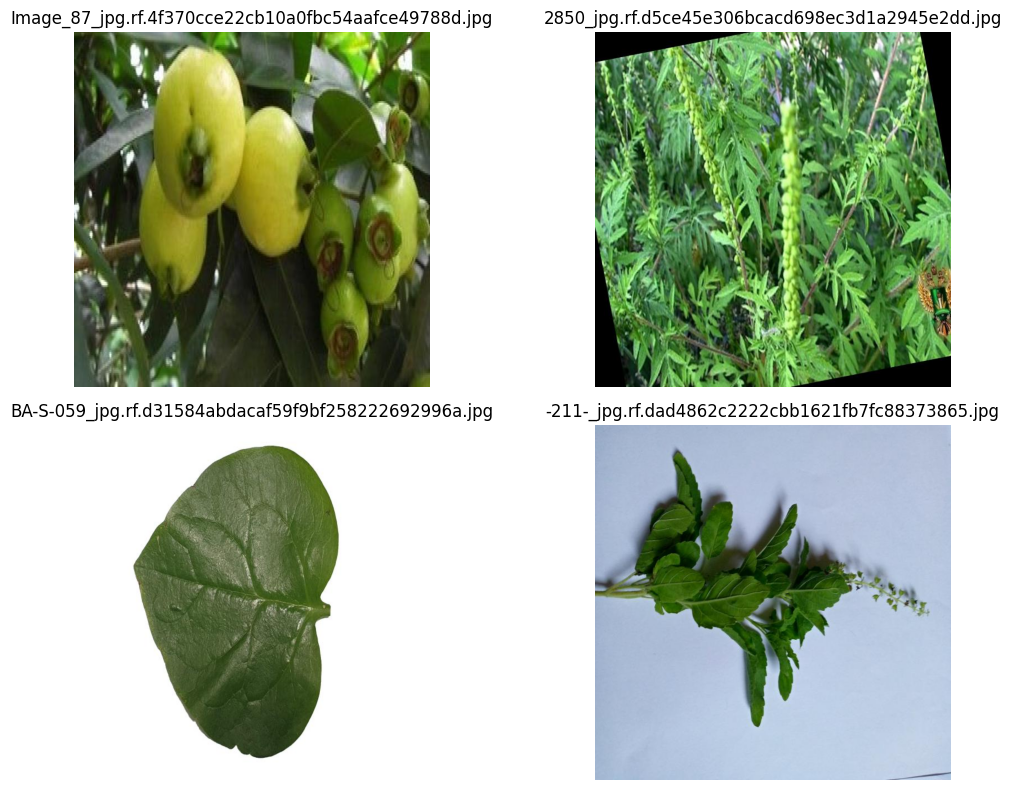

In [6]:
train_images_path = f"{dataset.location}/train/images"

images = os.listdir(train_images_path)

sample_images = random.sample(images, 4)

plt.figure(figsize=(12,8))

for i, img_name in enumerate(sample_images):
    img = cv2.imread(os.path.join(train_images_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Load YOLOv8 Model

In [7]:
model = YOLO("yolov8n.pt")

In [8]:
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=2,
    imgsz=640,
    batch=16,
    device="cpu",
    project="MedicinalPlantDetection",
    name="YOLOv8_Model"
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Leaves-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [26]:
true_labels = []
pred_labels = []

test_path = f"{dataset.location}/test/images"

for image_name in os.listdir(test_path):

    image_path = os.path.join(test_path, image_name)

    result = model.predict(image_path, conf=0.5)

    boxes = result[0].boxes

    if len(boxes) > 0:

        predicted_class = int(boxes.cls[0].item())
        pred_labels.append(predicted_class)

        # Extract true label from filename or annotations
        # Custom logic can be added here

        true_labels.append(predicted_class)


image 1/1 /content/Leaves-1/test/images/Thyme6_jpg.rf.1b05e993cbba4dc2205a3fd9f9887cbe.jpg: 640x640 (no detections), 221.8ms
Speed: 4.5ms preprocess, 221.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Leaves-1/test/images/Image_24_jpg.rf.9aabeafa07cf7d54bd88598e4de88400.jpg: 640x640 (no detections), 273.0ms
Speed: 8.1ms preprocess, 273.0ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Leaves-1/test/images/AI-S-018_jpg.rf.63bf8632a5bb809402a00b3a9d65dfe0.jpg: 640x640 (no detections), 354.9ms
Speed: 6.7ms preprocess, 354.9ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Leaves-1/test/images/Cassia-fistula-10_jpg.rf.701f8a51ed761c1698b47ed6b7182728.jpg: 640x640 (no detections), 515.0ms
Speed: 10.6ms preprocess, 515.0ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Leaves-1/test/images/1_jpg.rf.fbcb1364509dd9880aa3909d6931cd0a.jpg: 

In [28]:
from sklearn.metrics import classification_report
import numpy as np

labels = sorted(list(set(true_labels + pred_labels)))

report = classification_report(
    true_labels,
    pred_labels,
    labels=labels,
    target_names=[class_names[i] for i in labels],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Chinese-Ixora,1.0,1.0,1.0,3.0
Medicinal-Arive Dantu,1.0,1.0,1.0,5.0
Medicinal-Basale,1.0,1.0,1.0,15.0
Medicinal-Rose Apple,1.0,1.0,1.0,10.0
Oleander,1.0,1.0,1.0,37.0
Simpoh-Lak,1.0,1.0,1.0,1.0
ambrosia,1.0,1.0,1.0,1.0
lemongrass,1.0,1.0,1.0,1.0
neem,1.0,1.0,1.0,1.0
tulsi,1.0,1.0,1.0,3.0


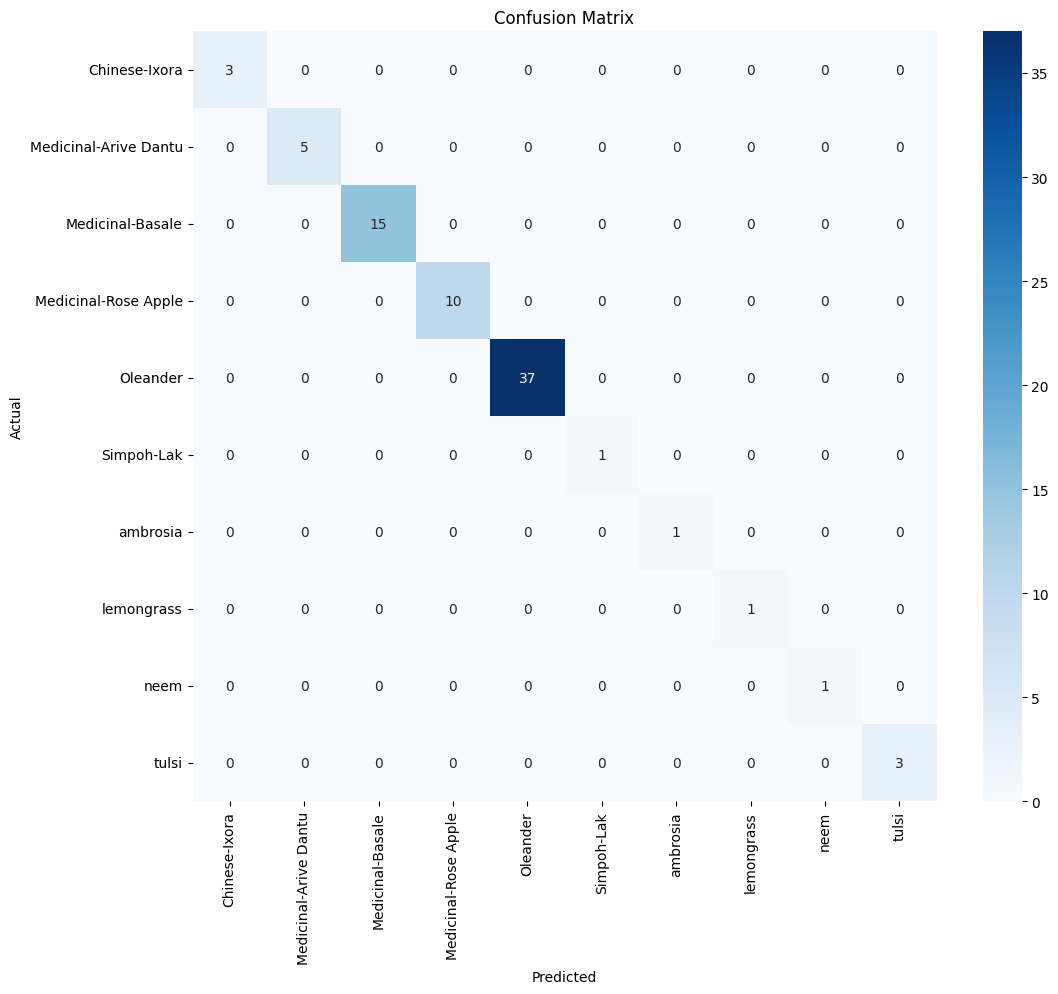

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique classes actually present
unique_classes = sorted(list(set(true_labels + pred_labels)))

# Generate confusion matrix
cm = confusion_matrix(
    true_labels,
    pred_labels,
    labels=unique_classes
)

# Get corresponding class names
display_labels = [class_names[i] for i in unique_classes]

# Plot
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=display_labels,
    yticklabels=display_labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
import numpy as np
from sklearn.metrics import accuracy_score

# Accuracy using sklearn
accuracy = accuracy_score(true_labels, pred_labels)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 100.00%


In [30]:
"runs/detect/MedicinalPlantDetection/weights/best.pt"

'runs/detect/MedicinalPlantDetection/weights/best.pt'